In [1]:
!git clone https://github.com/NhAnh278/llm-as-a-judge-praktikum.git

Cloning into 'llm-as-a-judge-praktikum'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 58 (delta 28), reused 23 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 880.13 KiB | 3.46 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [2]:
!git clone https://github.com/wmt-conference/wmt-mist.git

Cloning into 'wmt-mist'...
remote: Enumerating objects: 165, done.
remote: Total 165 (delta 0), reused 0 (delta 0), pack-reused 165 (from 1)
Receiving objects: 100% (165/165), 199.31 MiB | 10.69 MiB/s, done.
Resolving deltas: 100% (69/69), done.
Updating files: 100% (83/83), done.


In [3]:
%cd llm-as-a-judge-praktikum

/content/llm-as-a-judge-praktikum


In [4]:
!pip install -r requirements.txt

**Week 1: Load human-rating dataset**

In [5]:
%cd ..
%cd wmt-mist

/content
/content/wmt-mist


In [6]:
#load file human ratings
import json
import pandas as pd
from pathlib import Path

human_path = Path("data/humeval/oeg.json")
judge_dir = Path("data/submissions_judge_oeg")
mist_path = Path("data/mist_25.json")
with open(human_path, "r", encoding="utf-8") as f:
  human_data = json.load(f)
type(human_data), len(human_data)

(list, 7360)

In [7]:
#convert all data into DataFrame
df_human = pd.DataFrame(human_data)
df_human.head()

,system,prompt,response,doc_id,language_locale,coherence,naturalness,instruction_following,mean_score,rater,language
0,Gemma-3-12B,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,104373856e995a074579797ebe34fcb2,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater1_ar_EG,ar_EG
1,Gemma-3-12B,من فضلكم، أنا بتلقى رسائل إلكترونية دعائية بشك...,تمام، هذا طلب رسمي ومهم جدًا. إليك صيغة مُحسّن...,fb2c387e7e5272a43305940219116463,Egyptian Arabic,6.0,5.0,6.0,5.666667,rater2_ar_EG,ar_EG
2,Mistral-Medium,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,e91353a8c4dde03994b2cbfb5521172e,Egyptian Arabic,5.0,1.0,5.0,3.666667,rater2_ar_EG,ar_EG
3,Qwen3-235B,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,170d490a7ae53347e8fe3eabe4e28001,Egyptian Arabic,7.0,4.0,7.0,6.000000,rater3_ar_EG,ar_EG
4,CommandR7B,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,14e076d13751e87d8c09f7f13125e755,Egyptian Arabic,7.0,1.0,7.0,5.000000,rater3_ar_EG,ar_EG


In [8]:
df_human.shape

(7360, 11)

In [9]:
df_human.columns

Index(['system', 'prompt', 'response', 'doc_id', 'language_locale',
       'coherence', 'naturalness', 'instruction_following', 'mean_score',
       'rater', 'language'],
      dtype='object')

In [10]:
df_human[[
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]].describe()
#score is between 1 and 7
#naturalness has a lowest mean
#instruction_following looks really good with the highest mean score
#generally, human ratings are really high

,coherence,naturalness,instruction_following,mean_score
count,7360.000000,7360.000000,7360.000000,7360.000000
mean,5.790217,5.347554,5.869973,5.669248
std,1.588282,1.789316,1.496409,1.419300
min,1.000000,1.000000,1.000000,1.000000
25%,5.000000,5.000000,5.000000,5.000000
50%,7.000000,6.000000,7.000000,6.000000
75%,7.000000,7.000000,7.000000,7.000000
max,7.000000,7.000000,7.000000,7.000000


In [11]:
df_human["system"].value_counts()

,count
system,
Gemma-3-12B,460
Mistral-Medium,460
Qwen3-235B,460
CommandR7B,460
Llama-3,460
DeepSeek-V3,460
Mistral-7B,460
AyaExpanse-32B,460
Claude-4,460


In [12]:
df_human["language_locale"].value_counts()

,count
language_locale,
Egyptian Arabic,736
English (United States),736
German (Germany),736
Simplified Chinese (China),736
Hindi (India),736
Czech (Czechia),736
Indonesian (Indonesia),736
Japanese (Japan),736
Russian (Russia),736


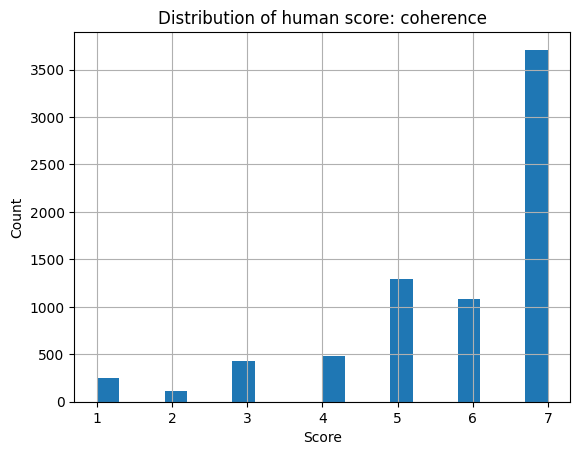

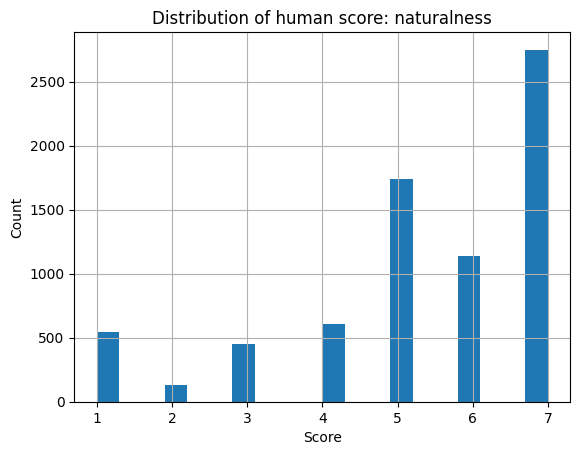

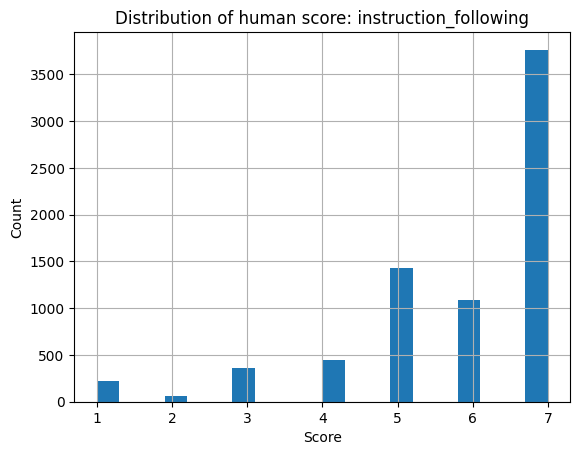

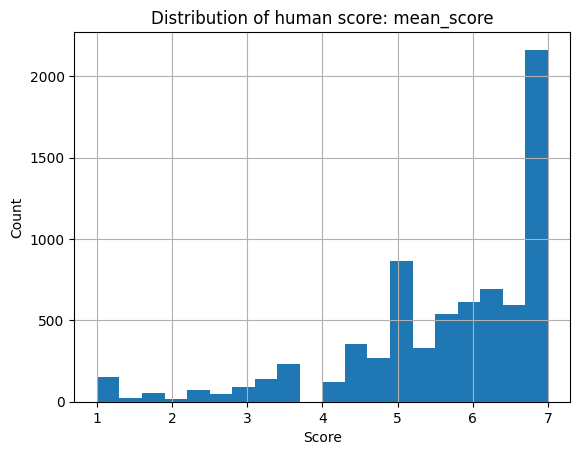

In [13]:
#plot human scores per aspect
score_cols = [
    "coherence",
    "naturalness",
    "instruction_following",
    "mean_score"
]

import matplotlib.pyplot as plt

for col in score_cols:
  plt.figure()
  df_human[col].hist(bins=20)
  plt.title(f"Distribution of human score: {col}")
  plt.xlabel("Score")
  plt.ylabel("Count")
  plt.show()

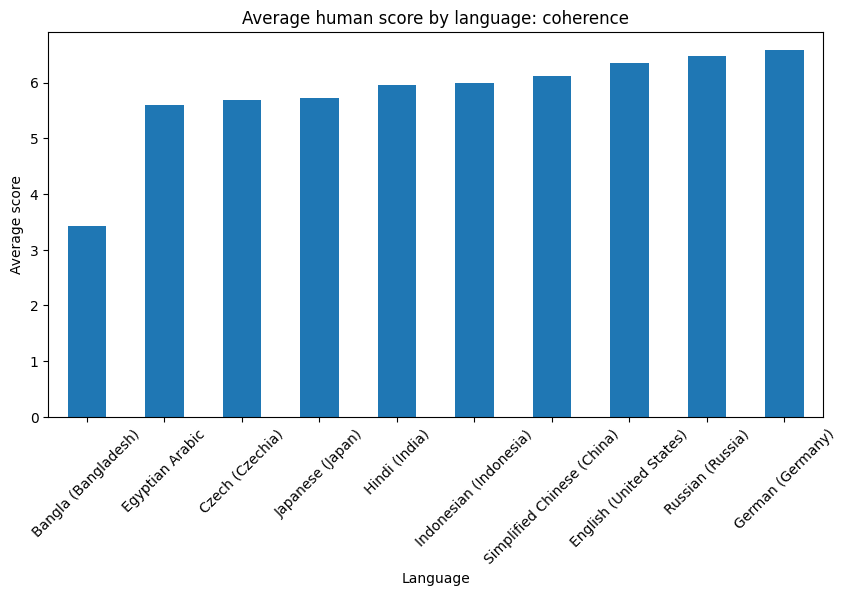

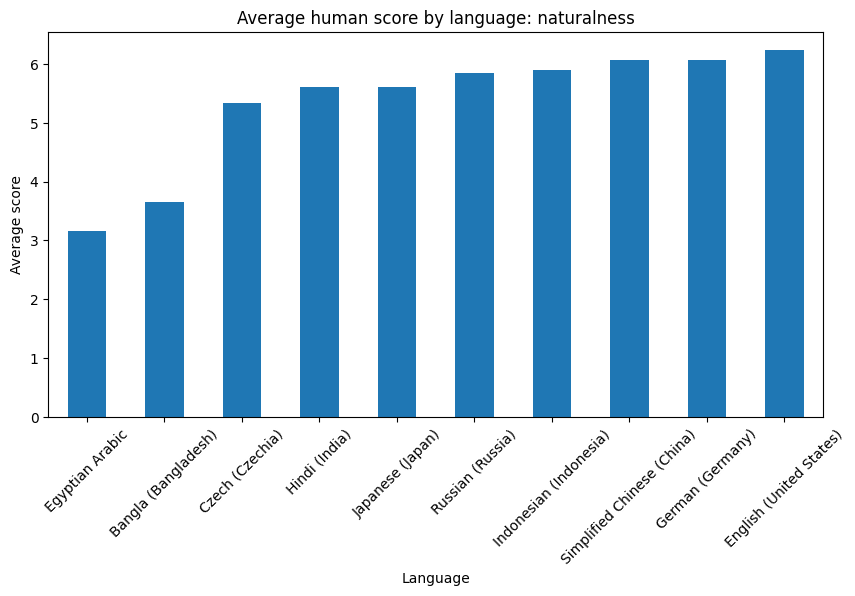

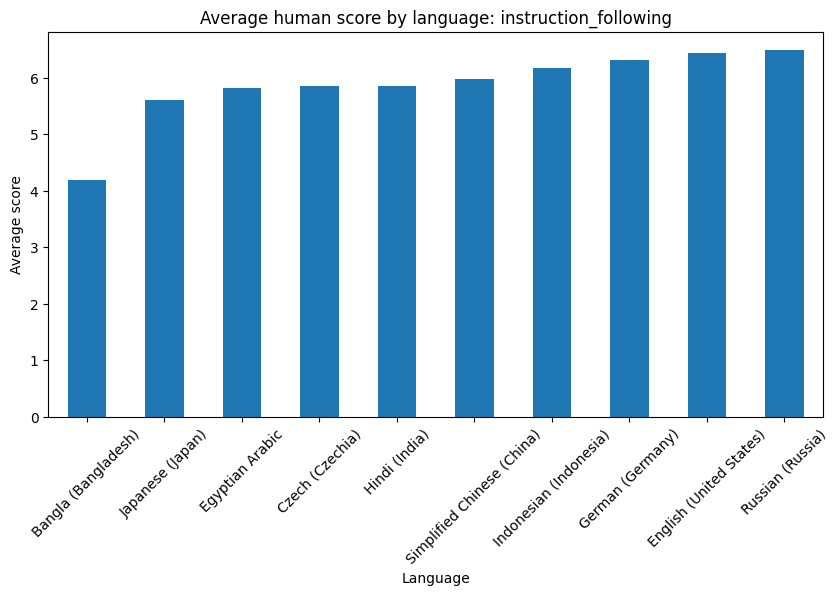

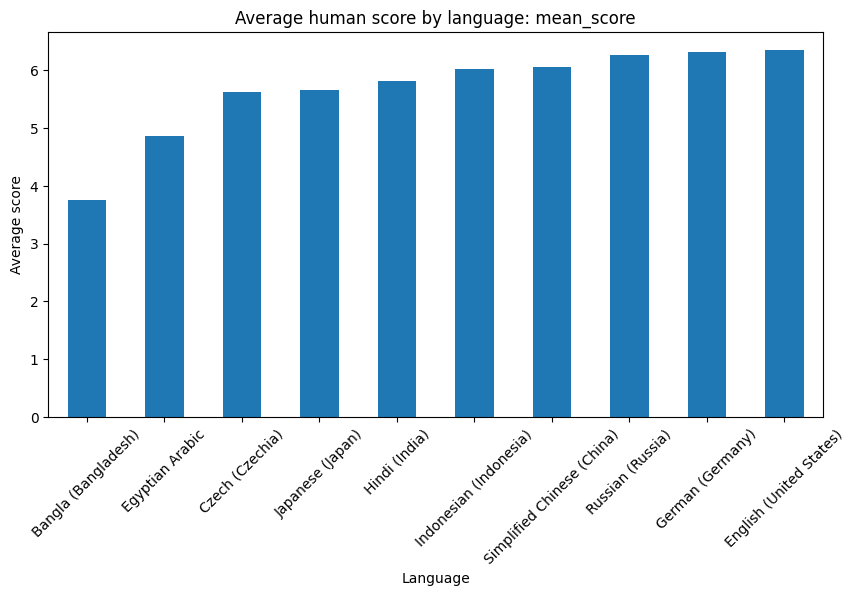

In [14]:
#Plot score per language
for col in score_cols:
    lang_scores = df_human.groupby("language_locale")[col].mean().sort_values()

    plt.figure(figsize=(10, 5))
    lang_scores.plot(kind="bar")
    plt.title(f"Average human score by language: {col}")
    plt.xlabel("Language")
    plt.ylabel("Average score")
    plt.xticks(rotation=45)
    plt.show()

In [15]:
#average human score by model
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

model_scores = (
    df_human
    .groupby("system")[score_cols]
    .mean()
    .sort_values("mean_score", ascending=False)
)

model_scores

,coherence,naturalness,instruction_following,mean_score
system,,,,
GPT-4,6.200000,5.936957,6.239130,6.125362
Gemini-2,6.215217,5.797826,6.247826,6.086957
DeepSeek-V3,6.091304,5.645652,6.169565,5.968841
Claude-4,6.082609,5.741304,6.056522,5.960145
Mistral-Medium,6.032609,5.680435,6.158696,5.957246
Gemma-3-27B,6.065217,5.591304,6.152174,5.936232
CommandA,6.028261,5.645652,6.119565,5.931159
Qwen3-235B,5.993478,5.565217,6.134783,5.897826
Llama-4-Maverick,5.930435,5.734783,6.017391,5.894203


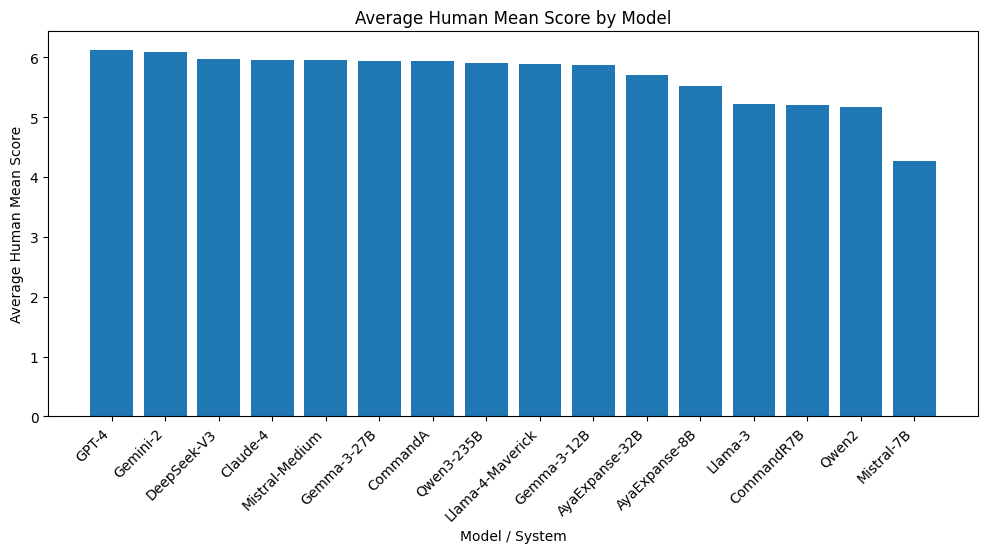

In [16]:
#plot mean_score by models
model_mean = (
    df_human
    .groupby("system")["mean_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))
plt.bar(model_mean.index, model_mean.values)
plt.title("Average Human Mean Score by Model")
plt.xlabel("Model / System")
plt.ylabel("Average Human Mean Score")
plt.xticks(rotation=45, ha="right")
plt.show()

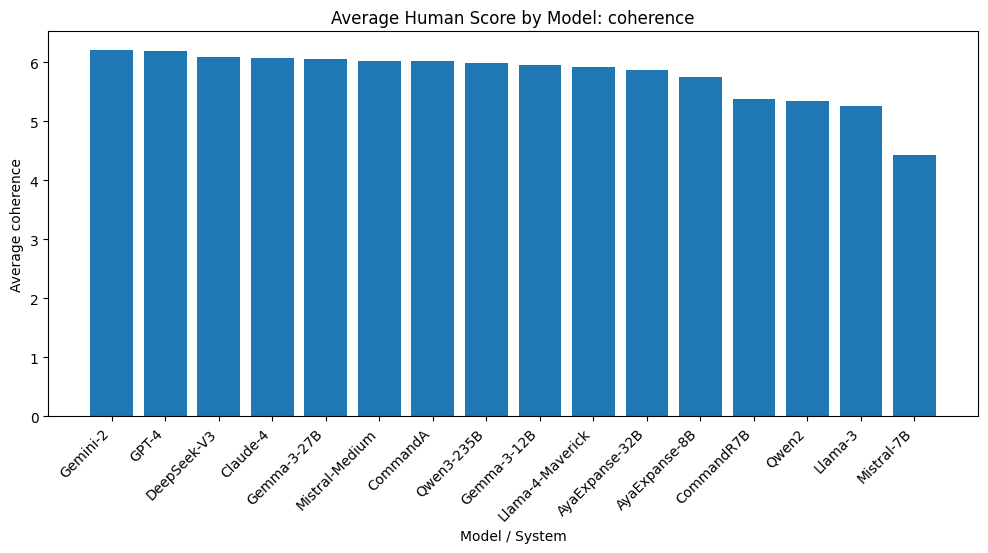

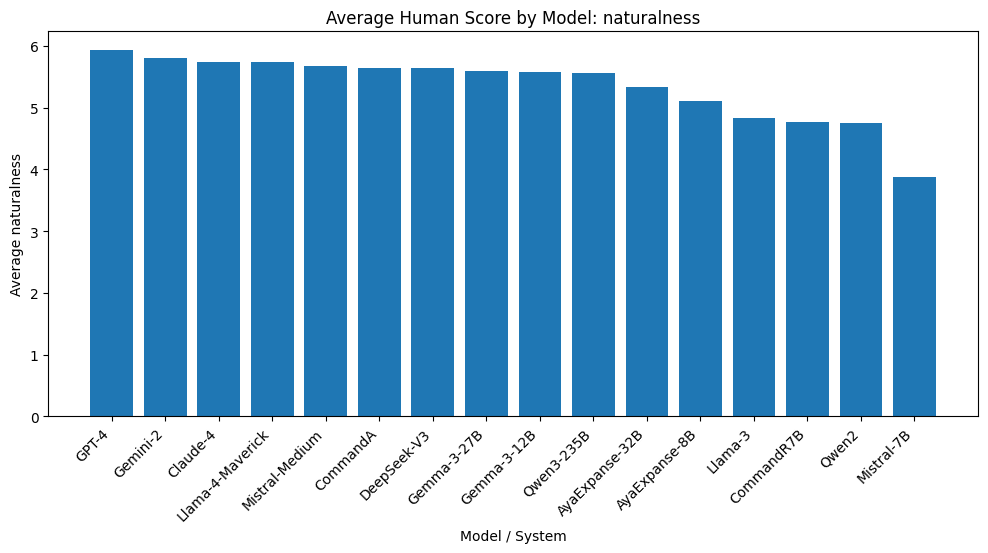

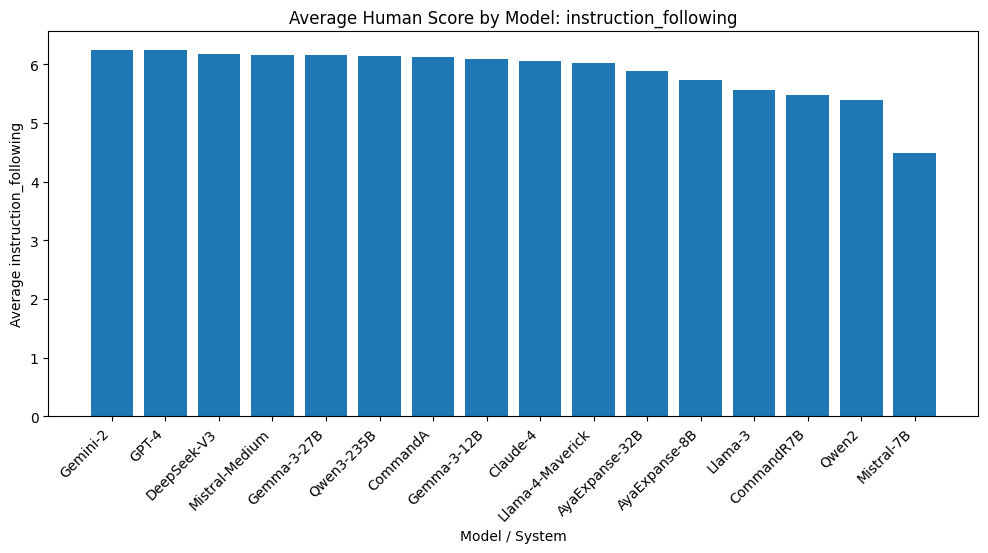

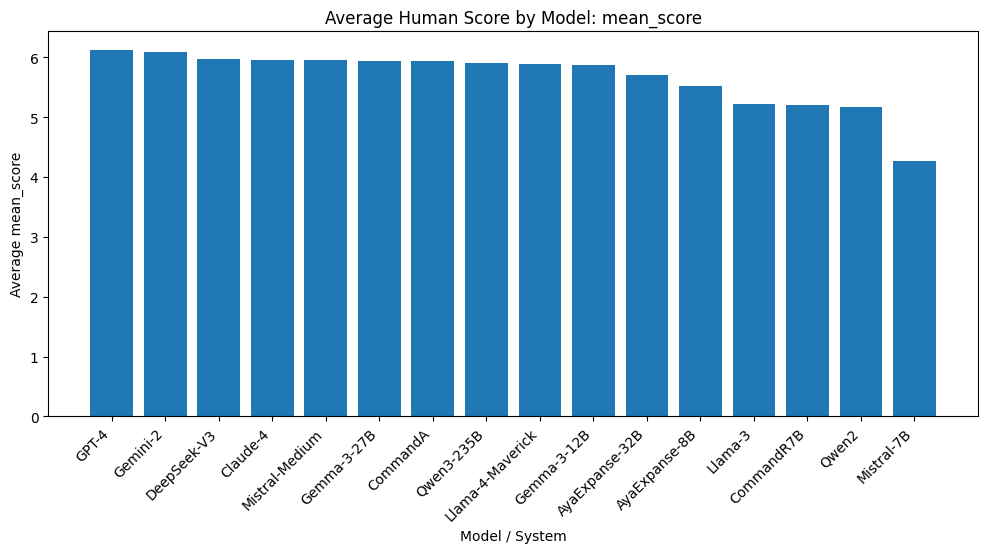

In [17]:
#plot for every aspect by models
for col in score_cols:
    model_scores_aspect = (
        df_human
        .groupby("system")[col]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))
    plt.bar(model_scores_aspect.index, model_scores_aspect.values)
    plt.title(f"Average Human Score by Model: {col}")
    plt.xlabel("Model / System")
    plt.ylabel(f"Average {col}")
    plt.xticks(rotation=45, ha="right")
    plt.show()

**Summary for week 1:**

**Week 2: Load judge model rating data**

In [18]:
#prepare human rating dataset with segment to merge later

#load mist to get segment_id
with open(mist_path, "r", encoding="utf-8") as f:
    mist_data = json.load(f)

df_mist = pd.DataFrame(mist_data)

df_mist_oeg = df_mist[
    df_mist["taskid"].str.startswith("open_ended_generation", na=False)
].copy()

#parse doc_id and segment_id
prefix = "open_ended_generation_"

df_mist_oeg["doc_segment"] = df_mist_oeg["taskid"].str.replace(prefix, "", regex=False)

df_mist_oeg["doc_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[0]
df_mist_oeg["segment_id"] = df_mist_oeg["doc_segment"].str.rsplit("_", n=1).str[1]

df_mist_oeg[["taskid", "doc_id", "segment_id", "prompt"]].head()


#create segment_map
df_segment_map = df_mist_oeg[
    ["doc_id", "segment_id", "prompt"]
].drop_duplicates()


#merge segment_id into human data
df_human_with_segment = df_human.merge(
    df_segment_map,
    on=["doc_id", "prompt"],
    how="left"
)

print("Missing segment_id:", df_human_with_segment["segment_id"].isna().sum())

#drop unmatch row
df_human_with_segment_clean = df_human_with_segment.dropna(
    subset=["segment_id"]
).copy()

print("Before:", len(df_human_with_segment))
print("After:", len(df_human_with_segment_clean))
print("Dropped:", len(df_human_with_segment) - len(df_human_with_segment_clean))


Missing segment_id: 16
Before: 7360
After: 7344
Dropped: 16


In [19]:
# convert human ratings to long format
score_cols = ["coherence", "naturalness", "instruction_following", "mean_score"]

df_human_long = df_human_with_segment_clean.melt(
    id_vars=[
        "doc_id",
        "segment_id",
        "system",
        "language",
        "language_locale",
        "prompt",
        "response"
    ],
    value_vars=score_cols,
    var_name="aspect",
    value_name="human_score"
)

df_human_long["segment_id"] = df_human_long["segment_id"].astype(int).astype(str)

df_human_long.head()

,doc_id,segment_id,system,language,language_locale,prompt,response,aspect,human_score
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B,ar_EG,Egyptian Arabic,إنت ممثل خدمة عملا في شركة تكنولوجيا. عميل كلم...,أهلاً بك [اسم العميل]،<br><br>شكرًا لك على الا...,coherence,7.0
1,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium,ar_EG,Egyptian Arabic,صاحبك القريب منك مسافر برة البلد ومتوتر إنه هي...,**عزيزي صديقي،**<br><br>أعلم أن هذه اللحظة ملي...,coherence,5.0
2,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B,ar_EG,Egyptian Arabic,اكتب حوار بالمصري بين اتنين صحاب، واحد فيهم بي...,**[موقف: صحابين قاعدين في الكافيتيريا، واحد من...,coherence,7.0
3,14e076d13751e87d8c09f7f13125e755,241,CommandR7B,ar_EG,Egyptian Arabic,أنا سكنت مؤخرًا في سكن طلاب. لاحظت إن واحد من ...,يمكنك كتابة ملحوظة لزقة على النحو التالي:<br><...,coherence,7.0
4,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3,ar_EG,Egyptian Arabic,اكتبلي مونولوج بالمصري، كإنه نهر بيحكي وبيقول ...,(نهر النيل يبدأ بالحديث)<br><br>يا لها من رحلة...,coherence,5.0


In [20]:
human_keys = df_human_with_segment_clean[
    ["doc_id", "segment_id", "system"]
].drop_duplicates()

human_keys["segment_id"] = human_keys["segment_id"].astype(int).astype(str)

human_keys.head()

,doc_id,segment_id,system
0,104373856e995a074579797ebe34fcb2,293,Gemma-3-12B
2,e91353a8c4dde03994b2cbfb5521172e,298,Mistral-Medium
3,170d490a7ae53347e8fe3eabe4e28001,288,Qwen3-235B
4,14e076d13751e87d8c09f7f13125e755,241,CommandR7B
5,c145f96bc4b6c5d0d18e06e89cb629bd,210,Llama-3


In [21]:
%cd ..
%cd llm-as-a-judge-praktikum
from src.utils import load_json, load_data

/content
/content/llm-as-a-judge-praktikum


In [22]:
%cd ..

/content


In [23]:
#load file

judge_dir = Path("wmt-mist/data/submissions_judge_oeg")

df_mistral_raw = load_data(judge_dir / "Mistral-7B.json")
df_qwen_raw = load_data(judge_dir / "Qwen2.5-7B.json")
df_commandr_raw = load_data(judge_dir / "CommandR7B.json")
df_llama_raw = load_data(judge_dir / "Llama-3.1-8B.json")


In [24]:
print("Mistral:", df_mistral_raw.shape)
print("Qwen:", df_qwen_raw.shape)
print("CommandR:", df_commandr_raw.shape)
print("Llama:", df_llama_raw.shape)

df_qwen_raw.head()

Mistral: (22560, 3)
Qwen: (22560, 3)
CommandR: (22560, 3)
Llama: (22560, 3)


,taskid,answer,tokens
0,judge_it_#_open_ended_generation_34ff7b0c7d176...,5,"{'input_tokens': 800, 'output_tokens': 2, 'thi..."
1,judge_coherence_#_open_ended_generation_34ff7b...,7,"{'input_tokens': 856, 'output_tokens': 2, 'thi..."
2,judge_natural_#_open_ended_generation_34ff7b0c...,7,"{'input_tokens': 799, 'output_tokens': 2, 'thi..."
3,judge_it_#_open_ended_generation_25206396b6f90...,3,"{'input_tokens': 1666, 'output_tokens': 2, 'th..."
4,judge_coherence_#_open_ended_generation_252063...,5,"{'input_tokens': 1722, 'output_tokens': 2, 'th..."


In [25]:
#process judge data frame function
aspect_map = {
    "judge_it": "instruction_following",
    "judge_coherence": "coherence",
    "judge_natural": "naturalness",
}

def process_judge_df(df_raw, judge_model_name):
    """
    Process one raw judge dataframe.

    Output columns:
    judge_model, doc_id, segment_id, system, aspect, judge_score
    """

    df = df_raw.copy()

    parts = df["taskid"].str.split("_#_", expand=True)

    df["judge_aspect_raw"] = parts[0]
    df["middle"] = parts[1]
    df["system"] = parts[2]

    prefix = "open_ended_generation_"
    df["doc_segment"] = df["middle"].str.replace(prefix, "", regex=False)

    df["doc_id"] = df["doc_segment"].str.rsplit("_", n=1).str[0]
    df["segment_id"] = df["doc_segment"].str.rsplit("_", n=1).str[1]

    df["aspect"] = df["judge_aspect_raw"].map(aspect_map)
    df["judge_score"] = pd.to_numeric(df["answer"], errors="coerce")

    df = df.dropna(subset=["aspect", "judge_score"]).copy()
    df["segment_id"] = df["segment_id"].astype(str)
    df["judge_model"] = judge_model_name

    df = df[
        ["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]
    ].copy()

    # Add judge mean_score = average of 3 judge aspects
    df_mean = (
        df
        .groupby(["judge_model", "doc_id", "segment_id", "system"], as_index=False)["judge_score"]
        .mean()
    )

    df_mean["aspect"] = "mean_score"

    df_with_mean = pd.concat(
        [
            df,
            df_mean[["judge_model", "doc_id", "segment_id", "system", "aspect", "judge_score"]]
        ],
        ignore_index=True
    )

    return df_with_mean

In [26]:
df_mistral = process_judge_df(df_mistral_raw, "Mistral-7B")
df_qwen = process_judge_df(df_qwen_raw, "Qwen2.5-7B")
df_commandr = process_judge_df(df_commandr_raw, "CommandR7B")
df_llama = process_judge_df(df_llama_raw, "Llama-3.1-8B")

In [27]:
#check result of transformation
for name, df in [
    ("Mistral-7B", df_mistral),
    ("Qwen2.5-7B", df_qwen),
    ("CommandR7B", df_commandr),
    ("Llama-3.1-8B", df_llama),
]:
    print(name, df.shape)
    print(df["aspect"].value_counts())
    print()

Mistral-7B (30080, 6)
aspect
instruction_following    7520
coherence                7520
naturalness              7520
mean_score               7520
Name: count, dtype: int64

Qwen2.5-7B (30080, 6)
aspect
instruction_following    7520
coherence                7520
naturalness              7520
mean_score               7520
Name: count, dtype: int64

CommandR7B (30080, 6)
aspect
instruction_following    7520
coherence                7520
naturalness              7520
mean_score               7520
Name: count, dtype: int64

Llama-3.1-8B (30080, 6)
aspect
instruction_following    7520
coherence                7520
naturalness              7520
mean_score               7520
Name: count, dtype: int64



In [28]:
#function to merge
def merge_judge_with_human(df_judge, df_human_long, human_keys):
    df_judge = df_judge.copy()
    df_human_long = df_human_long.copy()
    human_keys = human_keys.copy()

    df_judge["segment_id"] = df_judge["segment_id"].astype(str)
    df_human_long["segment_id"] = df_human_long["segment_id"].astype(str)
    human_keys["segment_id"] = human_keys["segment_id"].astype(str)

    df_judge_filtered = df_judge.merge(
        human_keys,
        on=["doc_id", "segment_id", "system"],
        how="inner"
    )

    df_merged = df_judge_filtered.merge(
        df_human_long,
        on=["doc_id", "segment_id", "system", "aspect"],
        how="inner"
    )

    print("Judge model:", df_judge["judge_model"].iloc[0])
    print("Judge rows before filtering:", len(df_judge))
    print("Judge rows after filtering:", len(df_judge_filtered))
    print("Merged rows:", len(df_merged))
    print("Merge rate:", len(df_merged) / len(df_judge_filtered))

    return df_merged

In [29]:
#merge
df_mistral_merged = merge_judge_with_human(df_mistral, df_human_long, human_keys)
df_qwen_merged = merge_judge_with_human(df_qwen, df_human_long, human_keys)
df_commandr_merged = merge_judge_with_human(df_commandr, df_human_long, human_keys)
df_llama_merged = merge_judge_with_human(df_llama, df_human_long, human_keys)

Judge model: Mistral-7B
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: Qwen2.5-7B
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: CommandR7B
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0
Judge model: Llama-3.1-8B
Judge rows before filtering: 30080
Judge rows after filtering: 29376
Merged rows: 29376
Merge rate: 1.0


In [30]:
#overall metrics function
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np
def safe_corr(x, y):
    x = pd.Series(x)
    y = pd.Series(y)

    if len(x) < 3:
        return np.nan, np.nan

    if x.nunique() <= 1 or y.nunique() <= 1:
        return np.nan, np.nan

    spearman, _ = spearmanr(x, y)
    pearson, _ = pearsonr(x, y)

    return spearman, pearson

def compute_overall_metrics(df_merged):
    df_eval = df_merged.dropna(subset=["human_score", "judge_score"])

    spearman, pearson = safe_corr(
        df_eval["human_score"],
        df_eval["judge_score"]
    )

    return {
        "judge_model": df_eval["judge_model"].iloc[0],
        "n": len(df_eval),
        "spearman": spearman,
        "pearson": pearson,
        "human_mean": df_eval["human_score"].mean(),
        "judge_mean": df_eval["judge_score"].mean(),
        "judge_minus_human": df_eval["judge_score"].mean() - df_eval["human_score"].mean()
    }

In [31]:
#comput_corelation_function
def compute_corr(df, human_col="human_score", judge_col="judge_score"):
    clean_df = df[[human_col, judge_col]].dropna()

    if len(clean_df) < 3:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    if clean_df[human_col].nunique() <= 1 or clean_df[judge_col].nunique() <= 1:
        return {
            "n": len(clean_df),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    spearman, _ = spearmanr(clean_df[human_col], clean_df[judge_col])
    pearson, _ = pearsonr(clean_df[human_col], clean_df[judge_col])

    return {
        "n": len(clean_df),
        "spearman": spearman,
        "pearson": pearson,
    }

In [32]:
overall_results = [
    compute_overall_metrics(df_mistral_merged),
    compute_overall_metrics(df_qwen_merged),
    compute_overall_metrics(df_commandr_merged),
    compute_overall_metrics(df_llama_merged),
]

df_overall = pd.DataFrame(overall_results).sort_values(
    "spearman",
    ascending=False
)

df_overall

,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
1,Qwen2.5-7B,29376,0.177562,0.239224,5.67352,6.170615,0.497095
2,CommandR7B,29376,0.161995,0.223444,5.67352,6.658224,0.984704
0,Mistral-7B,29376,0.122386,0.146365,5.67352,6.634622,0.961102
3,Llama-3.1-8B,29376,0.089752,0.186079,5.67352,6.014570,0.341049


In [33]:
aspect_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for aspect, group in df.groupby("aspect"):
        corr = compute_corr(group)

        aspect_results.append({
            "judge_model": name,
            "aspect": aspect,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_aspect = pd.DataFrame(aspect_results).sort_values(
    ["aspect", "spearman"],
    ascending=[True, False]
)

df_by_aspect

,judge_model,aspect,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
4,Qwen2.5-7B,coherence,7344,0.232252,0.283878,5.794254,5.946351,0.152097
0,Mistral-7B,coherence,7344,0.146930,0.194808,5.794254,6.567674,0.773420
12,Llama-3.1-8B,coherence,7344,0.137263,0.243763,5.794254,5.842320,0.048066
8,CommandR7B,coherence,7344,0.134824,0.210145,5.794254,6.689815,0.895561
9,CommandR7B,instruction_following,7344,0.215243,0.277422,5.874455,6.578159,0.703704
5,Qwen2.5-7B,instruction_following,7344,0.202272,0.276481,5.874455,6.012255,0.137800
13,Llama-3.1-8B,instruction_following,7344,0.147823,0.219578,5.874455,6.029684,0.155229
1,Mistral-7B,instruction_following,7344,0.097316,0.118741,5.874455,6.764706,0.890251
6,Qwen2.5-7B,mean_score,7344,0.246314,0.341499,5.673520,6.170615,0.497095
10,CommandR7B,mean_score,7344,0.184493,0.285063,5.673520,6.658224,0.984704


In [34]:
language_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for language, group in df.groupby("language_locale"):
        corr = compute_corr(group)

        language_results.append({
            "judge_model": name,
            "language_locale": language,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_language = pd.DataFrame(language_results).sort_values(
    ["language_locale", "spearman"],
    ascending=[True, False]
)

df_by_language

,judge_model,language_locale,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
10,Qwen2.5-7B,Bangla (Bangladesh),2944,0.347616,0.385121,3.756341,5.697464,1.941123
30,Llama-3.1-8B,Bangla (Bangladesh),2944,0.266677,0.366222,3.756341,5.765851,2.009511
20,CommandR7B,Bangla (Bangladesh),2944,0.178346,0.232414,3.756341,6.373641,2.617301
0,Mistral-7B,Bangla (Bangladesh),2944,0.067167,0.112627,3.756341,6.231431,2.475091
21,CommandR7B,Czech (Czechia),2944,0.135445,0.209637,5.624094,6.825181,1.201087
11,Qwen2.5-7B,Czech (Czechia),2944,0.074055,0.128590,5.624094,6.160779,0.536685
1,Mistral-7B,Czech (Czechia),2944,0.018227,0.083674,5.624094,6.758152,1.134058
31,Llama-3.1-8B,Czech (Czechia),2944,-0.024149,0.108991,5.624094,6.064764,0.440670
22,CommandR7B,Egyptian Arabic,2880,0.183309,0.240595,4.878704,6.615278,1.736574
12,Qwen2.5-7B,Egyptian Arabic,2880,0.132260,0.179572,4.878704,6.068519,1.189815


In [35]:
system_results = []

for name, df in [
    ("Mistral-7B", df_mistral_merged),
    ("Qwen2.5-7B", df_qwen_merged),
    ("CommandR7B", df_commandr_merged),
    ("Llama-3.1-8B", df_llama_merged),
]:
    for system, group in df.groupby("system"):
        corr = compute_corr(group)

        system_results.append({
            "judge_model": name,
            "judged_system": system,
            "n": corr["n"],
            "spearman": corr["spearman"],
            "pearson": corr["pearson"],
            "human_mean": group["human_score"].mean(),
            "judge_mean": group["judge_score"].mean(),
            "judge_minus_human": group["judge_score"].mean() - group["human_score"].mean()
        })

df_by_system = pd.DataFrame(system_results).sort_values(
    ["judged_system", "spearman"],
    ascending=[True, False]
)

df_by_system

,judge_model,judged_system,n,spearman,pearson,human_mean,judge_mean,judge_minus_human
16,Qwen2.5-7B,AyaExpanse-32B,1836,0.137486,0.146714,5.708061,6.320988,0.612927
32,CommandR7B,AyaExpanse-32B,1836,0.117741,0.116657,5.708061,6.785040,1.076979
0,Mistral-7B,AyaExpanse-32B,1836,0.106788,0.129739,5.708061,6.759622,1.051561
48,Llama-3.1-8B,AyaExpanse-32B,1836,0.067622,0.057022,5.708061,6.214960,0.506899
17,Qwen2.5-7B,AyaExpanse-8B,1836,0.200577,0.229071,5.525781,6.263617,0.737836
...,...,...,...,...,...,...,...,...
14,Mistral-7B,Qwen2,1836,0.110576,0.129996,5.175744,6.594771,1.419027
47,CommandR7B,Qwen3-235B,1836,0.087985,0.143073,5.899782,6.765432,0.865650
15,Mistral-7B,Qwen3-235B,1836,0.061623,0.062898,5.899782,6.746550,0.846768
31,Qwen2.5-7B,Qwen3-235B,1836,0.046663,0.035826,5.899782,6.459695,0.559913


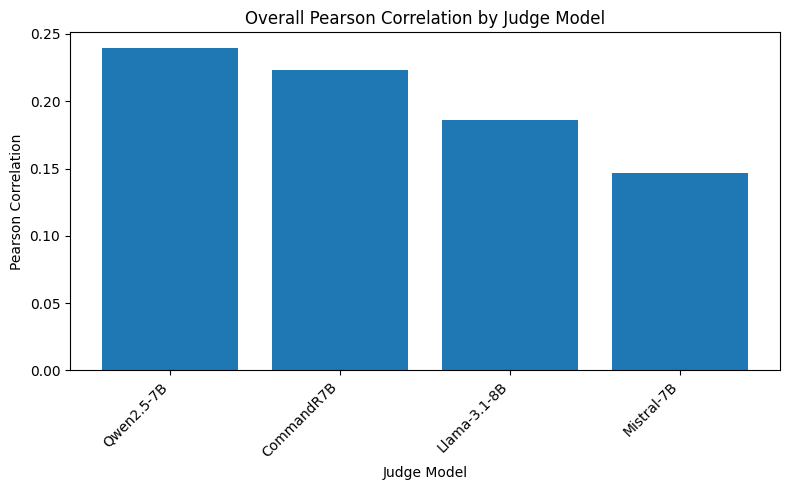

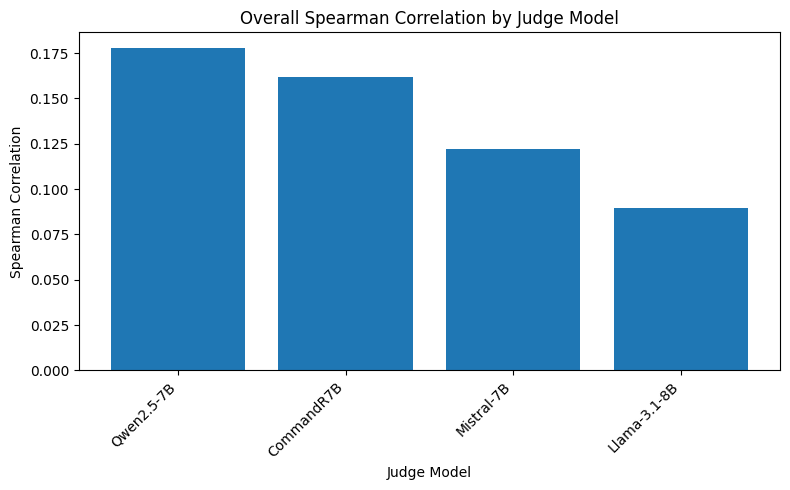

In [36]:
df_plot = df_overall.sort_values("pearson", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pearson"])

plt.title("Overall Pearson Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_pearson_by_judge.png", dpi=300)
plt.show()


df_plot = df_overall.sort_values("spearman", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["spearman"])

plt.title("Overall Spearman Correlation by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "overall_spearman_by_judge.png", dpi=300)
plt.show()

**Overall Pearson plot**
Qwen2.5-7B > CommandR7B > Llama-3.1-8B > Mistral-7B

**Overall Spearman plot**
Qwen2.5-7B > CommandR7B > Mistral-7B > Llama-3.1-8B

Qwen2.5-7B appears to be the strongest judge among the four selected models. However, the overall correlations are still weak, so these models should not be treated as reliable replacements for human evaluation.

Spearman is especially important here because the scores are on a 1–7 rating scale. A higher Spearman correlation means that the judge ranks responses more similarly to human raters.


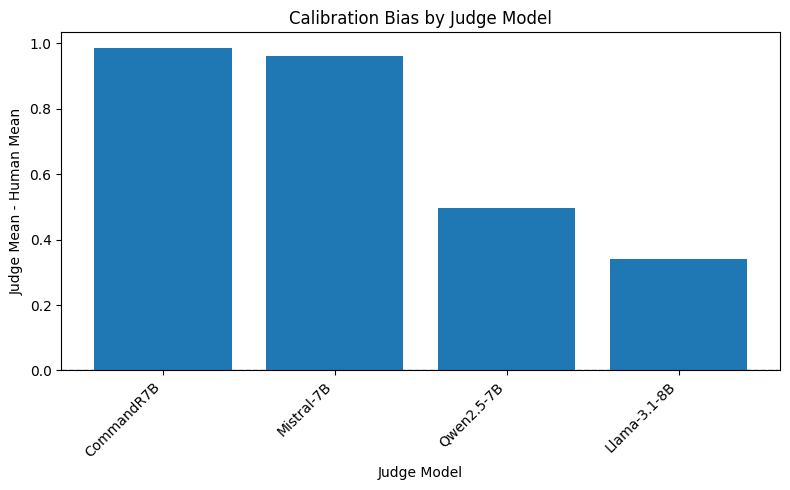

In [37]:
# Calibration bias by model
df_plot = df_overall.sort_values("judge_minus_human", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["judge_minus_human"])

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration Bias by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Judge Mean - Human Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

#plt.savefig(plots_dir / "calibration_bias_by_judge.png", dpi=300)
plt.show()

* All four judge models have a positive calibration bias.
* This means they generally give higher scores than human raters.
* CommandR7B and Mistral-7B show the strongest over-scoring bias.
* Qwen2.5-7B also over-scores, but less strongly.
* Llama-3.1-8B is closest to the human mean.


**better calibration does not necessarily mean better correlation!**

This means we should report both:

* correlation, to measure judge-human agreement;
* calibration bias, to measure whether the judge is too strict or too lenient.

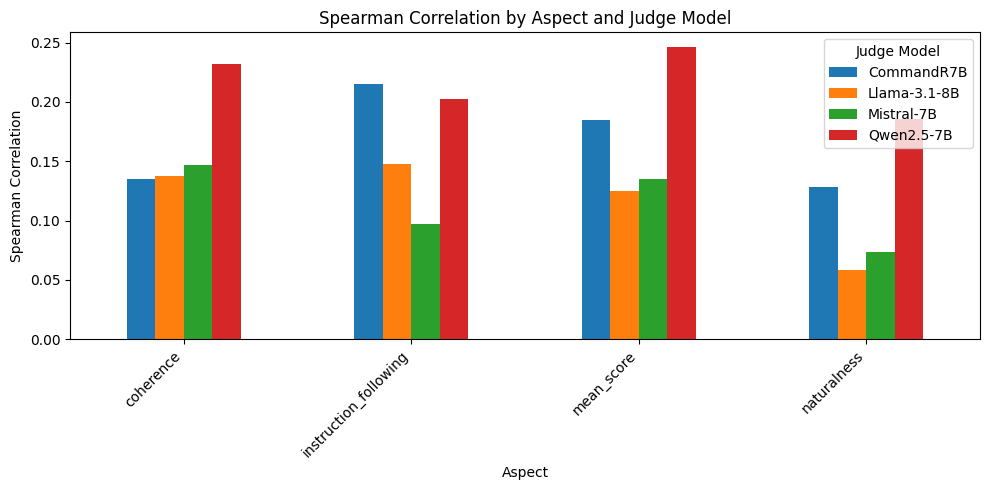

In [38]:
import matplotlib.pyplot as plt

pivot_aspect = df_by_aspect.pivot(
    index="aspect",
    columns="judge_model",
    values="spearman"
)

ax = pivot_aspect.plot(kind="bar", figsize=(10, 5))

plt.title("Spearman Correlation by Aspect and Judge Model")
plt.xlabel("Aspect")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Qwen2.5-7B performs best on several aspects
* CommandR7B performs particularly well on instruction following.
* Naturalness appears to be the most difficult aspect for most judges.
* Mistral-7B and Llama-3.1-8B are generally weaker or less stable across aspects.


Judge performance depends strongly on the evaluation criterion. Naturalness is especially difficult because it requires sensitivity to language-specific fluency, native-like wording, style, and cultural appropriateness.

Instruction following may be easier to judge because it is more directly connected to whether the response satisfies the prompt. Naturalness, by contrast, requires deeper knowledge of the target language.

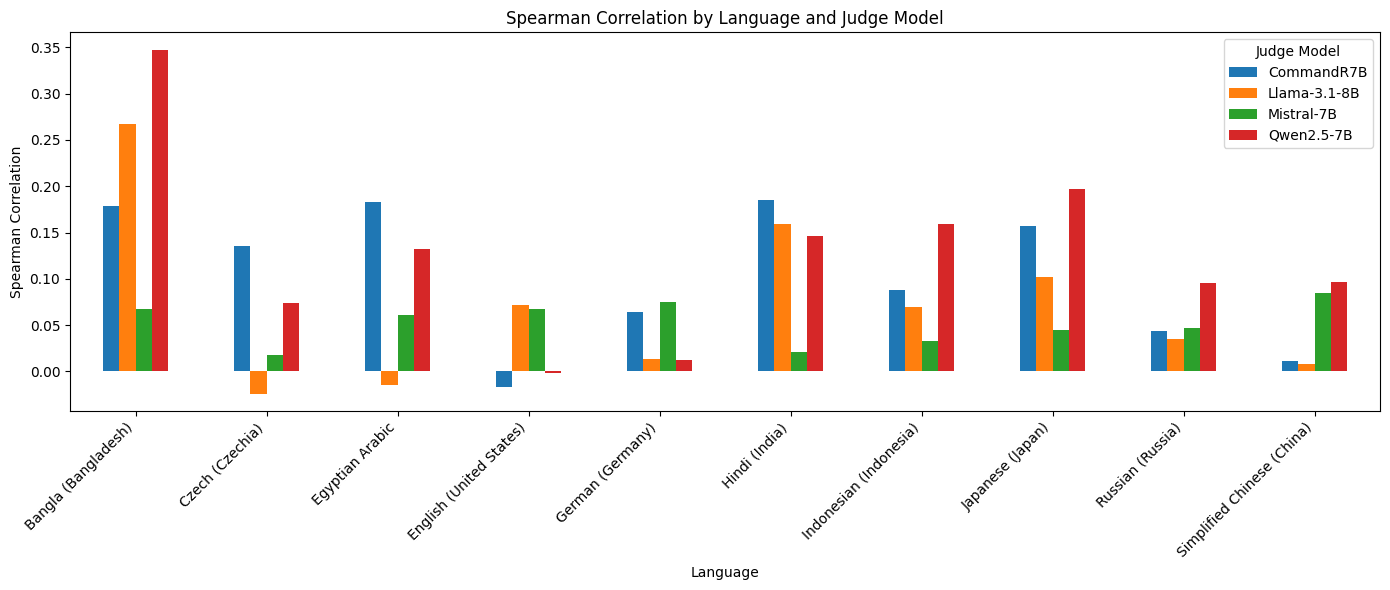

In [39]:
pivot_language = df_by_language.pivot(
    index="language_locale",
    columns="judge_model",
    values="spearman"
)

ax = pivot_language.plot(kind="bar", figsize=(14, 6))

plt.title("Spearman Correlation by Language and Judge Model")
plt.xlabel("Language")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

* Bangla shows the highest correlations, especially for Qwen2.5-7B.
* Hindi and Japanese also show relatively stronger results for some judges.
* English has near-zero or slightly negative correlation for some models.
* Czech and Egyptian Arabic also show weak or unstable correlations for several judges.
* The ranking of judge models changes depending on the language

There is clear evidence of language-level instability. The same judge model can perform reasonably well for one language but poorly for another.

This suggests that overall correlation is not enough for multilingual evaluation. A judge model may look acceptable overall, but still fail or become unreliable for specific languages.

Possible reasons include:

* different amounts of pretraining data for different languages;

* lower model sensitivity to dialects or regional language varieties;

* difficulty detecting local naturalness issues.

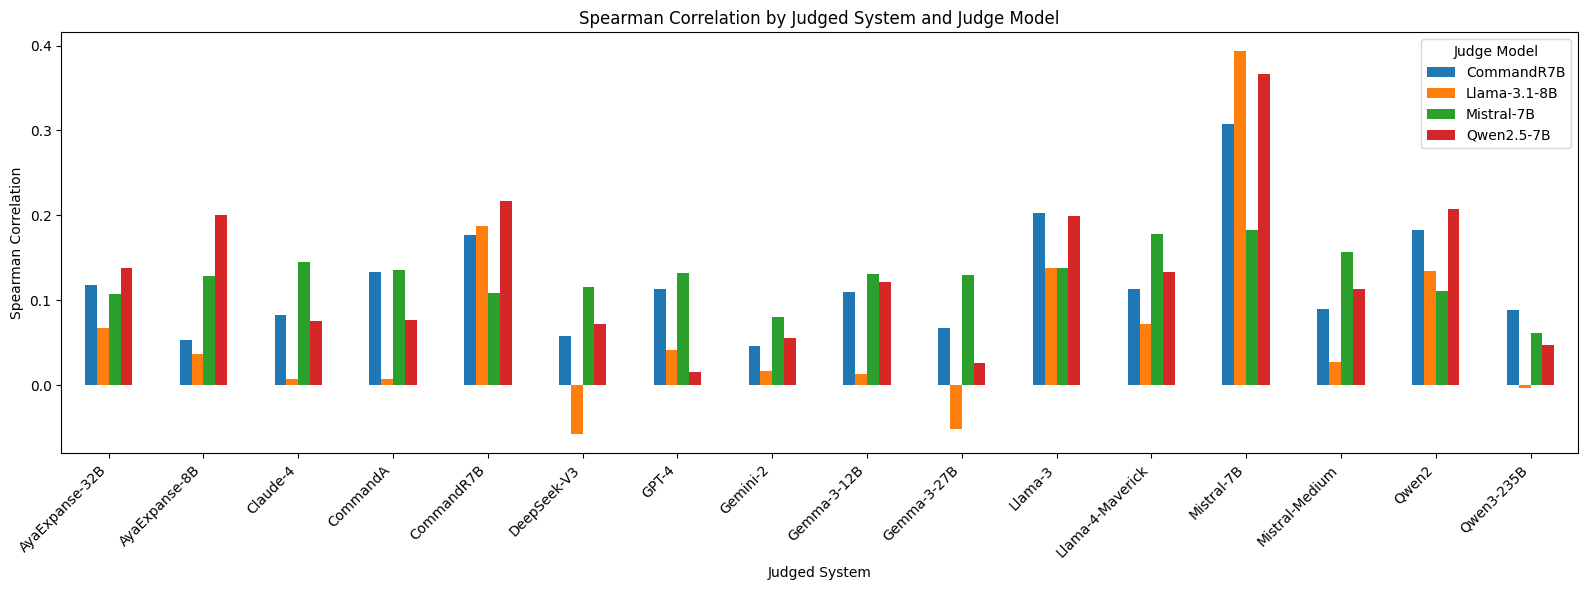

In [40]:
pivot_system = df_by_system.pivot(
    index="judged_system",
    columns="judge_model",
    values="spearman"
)

ax = pivot_system.plot(kind="bar", figsize=(16, 6))

plt.title("Spearman Correlation by Judged System and Judge Model")
plt.xlabel("Judged System")
plt.ylabel("Spearman Correlation")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Judge Model")
plt.tight_layout()
plt.show()

The judged-system plot analyzes whether judge-human agreement depends on the system whose output is being evaluated.


* Some judged systems show much higher correlations than others.
* Responses from Mistral-7B seem to produce relatively high judge-human agreement across several judges.
* Some systems show weak or even negative correlations for specific judge models.
* The same judge does not perform equally well across all judged systems.




**week 3: suitable metrics to calculate correlation**


In [41]:
all_merged = pd.concat(
    [
        df_mistral_merged,
        df_qwen_merged,
        df_commandr_merged,
        df_llama_merged,
    ],
    ignore_index=True
)

print(all_merged.shape)
all_merged[[
    "judge_model",
    "doc_id",
    "segment_id",
    "system",
    "language_locale",
    "aspect",
    "human_score",
    "judge_score"
]].head()

(117504, 11)


,judge_model,doc_id,segment_id,system,language_locale,aspect,human_score,judge_score
0,Mistral-7B,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),instruction_following,7.0,7.0
1,Mistral-7B,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),coherence,7.0,7.0
2,Mistral-7B,34ff7b0c7d176187b5f56965bc072870,0,Gemma-3-27B,English (United States),naturalness,7.0,7.0
3,Mistral-7B,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),instruction_following,5.0,6.0
4,Mistral-7B,25206396b6f90a56a632de9594cfa279,1,Gemma-3-27B,English (United States),coherence,5.0,6.0


main metrics are used:
- System-level: Pairwise Accuracy
- Segment/item-level: group-by-item acceq


In [42]:
from itertools import combinations
import numpy as np
import pandas as pd

In [43]:
def get_relation(score_a, score_b, tie_threshold=0.0):
    """
    Return relation between two scores:
    1  = A > B
    -1 = A < B
    0  = tie
    """
    diff = score_a - score_b

    if abs(diff) <= tie_threshold:
        return 0
    elif diff > 0:
        return 1
    else:
        return -1

In [44]:
def compute_system_pairwise_accuracy(
    df,
    group_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    tie_threshold=0.0,
):
    rows = []

    for group_key, group in df.groupby(group_cols):
        scores = (
            group
            .groupby(system_col)
            .agg(
                human_mean=(human_col, "mean"),
                judge_mean=(judge_col, "mean")
            )
            .reset_index()
        )

        correct = 0
        total = 0
        human_ties_ignored = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_mean"],
                scores.loc[b, "human_mean"],
                tie_threshold=tie_threshold
            )

            j_rel = get_relation(
                scores.loc[a, "judge_mean"],
                scores.loc[b, "judge_mean"],
                tie_threshold=tie_threshold
            )

            # system-level pairwise accuracy ignores human ties
            if h_rel == 0:
                human_ties_ignored += 1
                continue

            if h_rel == j_rel:
                correct += 1

            total += 1

        pairwise_accuracy = correct / total if total > 0 else np.nan

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = dict(zip(group_cols, group_key))
        row.update({
            "pairwise_accuracy": pairwise_accuracy,
            "correct_pairs": correct,
            "n_pairs": total,
            "human_ties_ignored": human_ties_ignored,
        })

        rows.append(row)

    return pd.DataFrame(rows)

In [45]:
df_pairwise_overall = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model"]
)

df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

,judge_model,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
3,Qwen2.5-7B,0.708333,85,120,0
1,Llama-3.1-8B,0.641667,77,120,0
0,CommandR7B,0.625000,75,120,0
2,Mistral-7B,0.558333,67,120,0


In [46]:
df_pairwise_by_aspect = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "aspect"]
)

df_pairwise_by_aspect.sort_values(
    ["aspect", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,aspect,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
12,Qwen2.5-7B,coherence,0.716667,86,120,0
0,CommandR7B,coherence,0.625000,75,120,0
4,Llama-3.1-8B,coherence,0.575000,69,120,0
8,Mistral-7B,coherence,0.550000,66,120,0
13,Qwen2.5-7B,instruction_following,0.766667,92,120,0
1,CommandR7B,instruction_following,0.675000,81,120,0
5,Llama-3.1-8B,instruction_following,0.625000,75,120,0
9,Mistral-7B,instruction_following,0.525000,63,120,0
14,Qwen2.5-7B,mean_score,0.708333,85,120,0
6,Llama-3.1-8B,mean_score,0.641667,77,120,0


In [47]:
df_pairwise_by_language = compute_system_pairwise_accuracy(
    all_merged,
    group_cols=["judge_model", "language_locale"]
)

df_pairwise_by_language.sort_values(
    ["language_locale", "pairwise_accuracy"],
    ascending=[True, False]
)

,judge_model,language_locale,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
30,Qwen2.5-7B,Bangla (Bangladesh),0.840336,100,119,1
10,Llama-3.1-8B,Bangla (Bangladesh),0.722689,86,119,1
20,Mistral-7B,Bangla (Bangladesh),0.571429,68,119,1
0,CommandR7B,Bangla (Bangladesh),0.563025,67,119,1
1,CommandR7B,Czech (Czechia),0.705882,84,119,1
31,Qwen2.5-7B,Czech (Czechia),0.689076,82,119,1
11,Llama-3.1-8B,Czech (Czechia),0.663866,79,119,1
21,Mistral-7B,Czech (Czechia),0.554622,66,119,1
32,Qwen2.5-7B,Egyptian Arabic,0.608333,73,120,0
2,CommandR7B,Egyptian Arabic,0.550000,66,120,0


In [48]:
def compute_acceq_by_item(
    df,
    item_cols,
    system_col="system",
    human_col="human_score",
    judge_col="judge_score",
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0,
):
    rows = []

    for item_key, group in df.groupby(item_cols):
        scores = (
            group
            .groupby(system_col)
            .agg(
                human_score=(human_col, "mean"),
                judge_score=(judge_col, "mean")
            )
            .reset_index()
        )

        C = 0
        D = 0
        T_h = 0
        T_m = 0
        T_hm = 0

        for a, b in combinations(scores.index, 2):
            h_rel = get_relation(
                scores.loc[a, "human_score"],
                scores.loc[b, "human_score"],
                tie_threshold=human_tie_threshold
            )

            j_rel = get_relation(
                scores.loc[a, "judge_score"],
                scores.loc[b, "judge_score"],
                tie_threshold=judge_tie_threshold
            )

            if h_rel == 0 and j_rel == 0:
                T_hm += 1
            elif h_rel == 0 and j_rel != 0:
                T_h += 1
            elif h_rel != 0 and j_rel == 0:
                T_m += 1
            elif h_rel == j_rel:
                C += 1
            else:
                D += 1

        total = C + D + T_h + T_m + T_hm
        acceq = (C + T_hm) / total if total > 0 else np.nan

        if not isinstance(item_key, tuple):
            item_key = (item_key,)

        row = dict(zip(item_cols, item_key))
        row.update({
            "acceq": acceq,
            "C": C,
            "D": D,
            "T_h": T_h,
            "T_m": T_m,
            "T_hm": T_hm,
            "n_pairs": total,
        })

        rows.append(row)

    return pd.DataFrame(rows)

In [49]:
item_cols = [
    "judge_model",
    "doc_id",
    "segment_id",
    "language_locale",
    "aspect"
]
df_acceq_items = compute_acceq_by_item(
    all_merged,
    item_cols=item_cols,
    human_tie_threshold=0.0,
    judge_tie_threshold=0.0
)

df_acceq_items.head()

,judge_model,doc_id,segment_id,language_locale,aspect,acceq,C,D,T_h,T_m,T_hm,n_pairs
0,CommandR7B,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),coherence,0.225000,0,0,0,93,27,120
1,CommandR7B,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),instruction_following,1.000000,0,0,0,0,120,120
2,CommandR7B,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),mean_score,0.200000,0,0,0,96,24,120
3,CommandR7B,0a3da1ceeb83f664b813bb28f001d766,1170,Indonesian (Indonesia),naturalness,0.508333,0,0,0,59,61,120
4,CommandR7B,0a3da1ceeb83f664b813bb28f001d766,1370,Japanese (Japan),coherence,0.658333,0,0,0,41,79,120


In [50]:
df_acceq_overall = (
    df_acceq_items
    .groupby("judge_model", as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values("acceq", ascending=False)
)

df_acceq_overall

,judge_model,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
3,Qwen2.5-7B,0.462722,1836,120.0,37399,18477,33454,66442,64548
0,CommandR7B,0.459818,1836,120.0,21042,11029,17737,90247,80265
2,Mistral-7B,0.422072,1836,120.0,22630,20953,27641,78735,70361
1,Llama-3.1-8B,0.422013,1836,120.0,36044,24914,41068,61360,56934


In [51]:
df_acceq_by_aspect = (
    df_acceq_items
    .groupby(["judge_model", "aspect"], as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values(["aspect", "acceq"], ascending=[True, False])
)

df_acceq_by_aspect

,judge_model,aspect,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
0,CommandR7B,coherence,0.513689,459,120.0,3962,1785,4212,20789,24332
12,Qwen2.5-7B,coherence,0.479775,459,120.0,6670,3258,8788,16608,19756
4,Llama-3.1-8B,coherence,0.468682,459,120.0,5995,3440,8724,17101,19820
8,Mistral-7B,coherence,0.446605,459,120.0,5009,4435,8954,17092,19590
1,CommandR7B,instruction_following,0.523856,459,120.0,4466,2143,5456,18627,24388
9,Mistral-7B,instruction_following,0.498693,459,120.0,2587,2436,4963,20213,24881
13,Qwen2.5-7B,instruction_following,0.486220,459,120.0,7728,3398,10791,14110,19053
5,Llama-3.1-8B,instruction_following,0.443519,459,120.0,6994,4422,12409,13820,17435
14,Qwen2.5-7B,mean_score,0.421333,459,120.0,15958,9024,8306,14543,7249
6,Llama-3.1-8B,mean_score,0.375763,459,120.0,15074,11223,9932,13228,5623


In [52]:
df_acceq_by_language = (
    df_acceq_items
    .groupby(["judge_model", "language_locale"], as_index=False)
    .agg(
        acceq=("acceq", "mean"),
        n_items=("acceq", "size"),
        avg_pairs=("n_pairs", "mean"),
        total_C=("C", "sum"),
        total_D=("D", "sum"),
        total_T_h=("T_h", "sum"),
        total_T_m=("T_m", "sum"),
        total_T_hm=("T_hm", "sum"),
    )
    .sort_values(["language_locale", "acceq"], ascending=[True, False])
)

df_acceq_by_language

,judge_model,language_locale,acceq,n_items,avg_pairs,total_C,total_D,total_T_h,total_T_m,total_T_hm
30,Qwen2.5-7B,Bangla (Bangladesh),0.448098,184,120.0,6244,2115,2424,7647,3650
10,Llama-3.1-8B,Bangla (Bangladesh),0.412183,184,120.0,5624,2440,2597,7942,3477
0,CommandR7B,Bangla (Bangladesh),0.366576,184,120.0,3908,2415,1888,9683,4186
20,Mistral-7B,Bangla (Bangladesh),0.336141,184,120.0,4624,4237,3276,7145,2798
31,Qwen2.5-7B,Czech (Czechia),0.378623,184,120.0,4279,2622,2244,8854,4081
11,Llama-3.1-8B,Czech (Czechia),0.359828,184,120.0,4398,3569,2778,7788,3547
1,CommandR7B,Czech (Czechia),0.342754,184,120.0,1948,977,705,12830,5620
21,Mistral-7B,Czech (Czechia),0.329937,184,120.0,2065,1996,1105,11694,5220
2,CommandR7B,Egyptian Arabic,0.485509,180,120.0,2988,918,1901,8294,7499
32,Qwen2.5-7B,Egyptian Arabic,0.477778,180,120.0,4633,1736,3713,5831,5687


In [53]:
df_metric_compare = (
    df_overall
    .merge(
        df_pairwise_overall[["judge_model", "pairwise_accuracy"]],
        on="judge_model",
        how="left"
    )
    .merge(
        df_acceq_overall[["judge_model", "acceq"]],
        on="judge_model",
        how="left"
    )
)

df_metric_compare.sort_values("acceq", ascending=False)

,judge_model,n,spearman,pearson,human_mean,judge_mean,judge_minus_human,pairwise_accuracy,acceq
0,Qwen2.5-7B,29376,0.177562,0.239224,5.67352,6.170615,0.497095,0.708333,0.462722
1,CommandR7B,29376,0.161995,0.223444,5.67352,6.658224,0.984704,0.625000,0.459818
2,Mistral-7B,29376,0.122386,0.146365,5.67352,6.634622,0.961102,0.558333,0.422072
3,Llama-3.1-8B,29376,0.089752,0.186079,5.67352,6.014570,0.341049,0.641667,0.422013


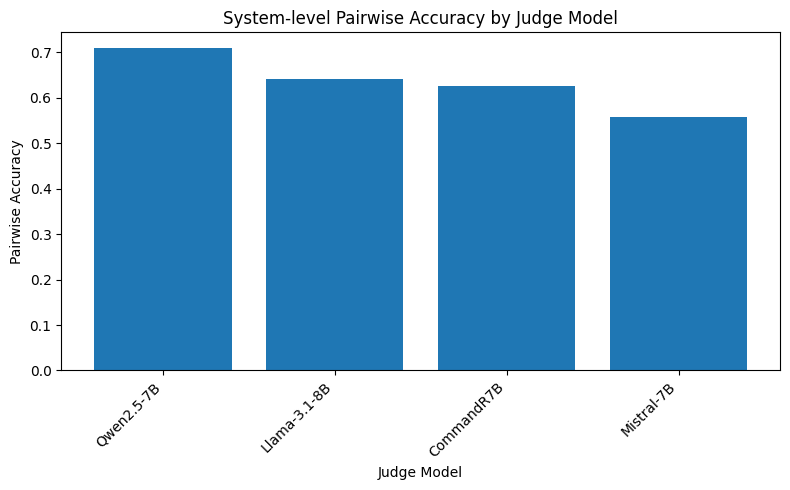

In [54]:
#overall pairwise accuracy
import matplotlib.pyplot as plt

df_plot = df_pairwise_overall.sort_values("pairwise_accuracy", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["pairwise_accuracy"])
plt.title("System-level Pairwise Accuracy by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("Pairwise Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

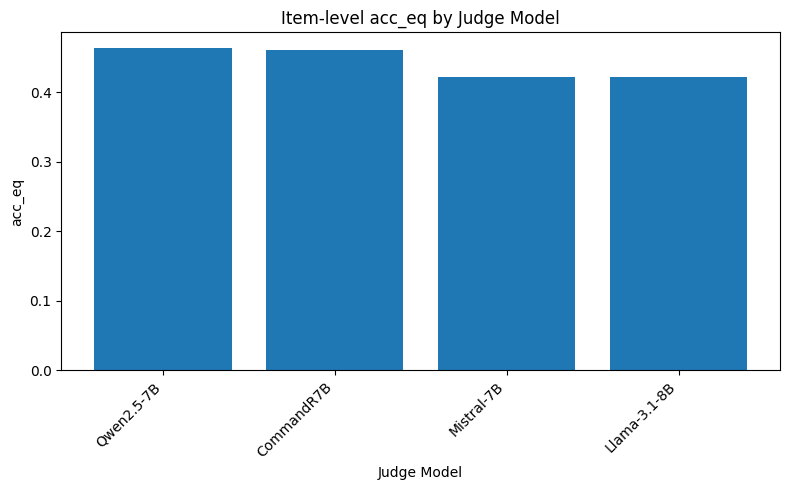

In [55]:
df_plot = df_acceq_overall.sort_values("acceq", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["judge_model"], df_plot["acceq"])
plt.title("Item-level acc_eq by Judge Model")
plt.xlabel("Judge Model")
plt.ylabel("acc_eq")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Pairwise Accuracy and acc_eq

The previous analysis used Pearson and Spearman correlations between human and judge scores. However, the findings paper also uses pairwise ranking-based metrics. Therefore, we add system-level Pairwise Accuracy and item-level acc_eq.

System-level Pairwise Accuracy checks whether the judge ranks systems in the same order as human ratings after aggregating scores by system.

Item-level acc_eq compares all pairs of system outputs within the same item and gives credit both for correct orderings and correctly predicted ties.

**Week 4: Load lightweight model**

Test lightweight instruction-tuned models such as Qwen2.5-1.5B-Instruct, Qwen2.5-3B-Instruct, and Gemma-2-2B-IT.

Try a more multilingual-focused model such as Aya-Expanse-8B.

In [56]:
!pip install -q transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.1 MB/s eta 0:00:00


In [57]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [72]:
hf_sample = (
    df_human_long[
        (df_human_long["language_locale"] == "English (United States)") &
        (df_human_long["aspect"].isin([
            "coherence",
            "naturalness",
            "instruction_following"
        ]))
    ]
    .groupby("human_score", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5), random_state=42))
    .reset_index(drop=True)
)

print(hf_sample.shape)
hf_sample["human_score"].value_counts().sort_index()

(30, 9)


/tmp/ipykernel_5859/2770454919.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5), random_state=42))


,count
human_score,
2.0,5
3.0,5
4.0,5
5.0,5
6.0,5
7.0,5


In [61]:
judge_model_1 = "Qwen/Qwen2.5-1.5B-Instruct"
judge_model_2 = "Qwen/Qwen2.5-3B-Instruct"
judge_model_3 = "mistralai/Mistral-7B-Instruct-v0.3"

In [62]:
#Load model
tokenizer = AutoTokenizer.from_pretrained(judge_model_3)

model = AutoModelForCausalLM.from_pretrained(
    judge_model_3,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/141k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): MistralRMSNorm((4096,)

In [63]:
def direct_prompt(row):
    return f"""You are an evaluator for multilingual open-ended generation.

Your task is to evaluate the response according to the given aspect.

Aspect:
{row["aspect"]}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [93]:
def generate_judge_output(prompt, max_new_tokens=150):
    messages = [
        {"role": "user", "content": prompt}
    ]

    if hasattr(tokenizer, "apply_chat_template"):
        input_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    else:
        input_text = prompt

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=4096
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    output_text = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return output_text.strip()

In [65]:
def parse_score(text):
    """
    Extract first integer score from 1 to 7.
    """
    match = re.search(r"\b([1-7])\b", str(text))
    if match:
        return int(match.group(1))
    return np.nan

In [89]:
hf_outputs = []

for count, (idx, row) in enumerate(hf_sample.iterrows(), start=1):
    prompt = direct_prompt(row)
    output = generate_judge_output(prompt)
    score = parse_score(output)

    hf_outputs.append({
        "index": idx,
        "hf_raw_output": output,
        "judge_score": score,
    })

    if count % 10 == 0:
        print(f"Processed {count}/{len(hf_sample)}")

Processed 10/30
Processed 20/30
Processed 30/30


In [74]:
df_hf_outputs = pd.DataFrame(hf_outputs)

df_hf_outputs.head()

,index,hf_raw_output,judge_score
0,0,5 (good),5
1,1,6 (very good,6
2,2,5 (good),5
3,3,6,6
4,4,6,6


In [75]:
df_hf_judge = hf_sample.reset_index().merge(
    df_hf_outputs,
    on="index",
    how="left"
)

df_hf_judge["judge_model"] = judge_model_2

df_hf_judge[
    ["language_locale", "system", "aspect", "human_score", "judge_score"]
].head()

,language_locale,system,aspect,human_score,judge_score
0,English (United States),Mistral-7B,coherence,2.0,5
1,English (United States),Llama-3,coherence,2.0,6
2,English (United States),Mistral-7B,instruction_following,2.0,5
3,English (United States),Gemini-2,naturalness,2.0,6
4,English (United States),Llama-3,instruction_following,2.0,6


**Week 5: try some different types of prompt**

- direct scoring prompt is the baseline
- aspect-specific / rubric-based prompts
- rational + final score prompt
- scoring with uncertainty intervals

In [85]:
def aspect_specific_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        aspect_instruction = """
Evaluate ONLY coherence.

Focus on:
- logical consistency
- clear structure
- whether ideas connect well
- whether the response is easy to follow
- contradictions or confusing parts

Do NOT penalize mainly for:
- unnatural wording, unless it makes the response hard to understand
- small instruction-following issues, unless they make the response incoherent
"""
    elif aspect == "naturalness":
        aspect_instruction = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Focus on:
- fluency in {language}
- idiomatic and native-like wording
- natural sentence structure
- whether the response sounds like something a fluent speaker would write
- awkward, translated, or unnatural phrasing

Do NOT penalize mainly for:
- missing content, unless it makes the language unnatural
- instruction-following issues, unless they directly affect naturalness
"""
    elif aspect == "instruction_following":
        aspect_instruction = """
Evaluate ONLY instruction following.

Focus on:
- whether the response answers the user's request
- whether it follows all explicit constraints
- whether it uses the requested format, style, language, length, or content
- whether important parts of the instruction are missing

Do NOT penalize mainly for:
- unnatural wording, unless it prevents task completion
- minor coherence issues, unless they make the response fail the instruction
"""
    else:
        aspect_instruction = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{aspect_instruction}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Return only one integer from 1 to 7. Do not explain.

User prompt:
{row["prompt"]}

Response:
{row["response"]}

Score:"""

In [86]:
outputs = []

for i, row in hf_sample.iterrows():
    prompt = aspect_specific_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_aspect_specific_prompt = pd.DataFrame(outputs)

[1/30] English (United States) | coherence | human=2.0 | judge=6 | raw=6
[2/30] English (United States) | coherence | human=2.0 | judge=6 | raw=6
[3/30] English (United States) | instruction_following | human=2.0 | judge=5 | raw=5
[4/30] English (United States) | naturalness | human=2.0 | judge=6 | raw=6
[5/30] English (United States) | instruction_following | human=2.0 | judge=6 | raw=6
[6/30] English (United States) | instruction_following | human=3.0 | judge=7 | raw=7 (excell
[7/30] English (United States) | instruction_following | human=3.0 | judge=6 | raw=6
[8/30] English (United States) | coherence | human=3.0 | judge=6 | raw=6
[9/30] English (United States) | instruction_following | human=3.0 | judge=6 | raw=6
[10/30] English (United States) | coherence | human=3.0 | judge=6 | raw=6 (very good
[11/30] English (United States) | instruction_following | human=4.0 | judge=6 | raw=6
[12/30] English (United States) | instruction_following | human=4.0 | judge=6 | raw=6
[13/30] English 

In [87]:
df_hf_judge["judge_score"].value_counts(dropna=False).sort_index()
df_aspect_specific_prompt["judge_score"].value_counts(dropna=False).sort_index()

,count
judge_score,
5,1
6,20
7,9


In [90]:
def rationale_final_score_prompt(row):
    aspect = row["aspect"]
    language = row.get("language_locale", "the target language")

    if aspect == "coherence":
        criterion = """
Evaluate ONLY coherence.

Coherence means:
- logical consistency;
- clear structure;
- ideas connect well;
- the response is easy to follow;
- no contradictions or confusing jumps.

Do not mainly judge naturalness or instruction following unless they directly affect coherence.
"""

    elif aspect == "naturalness":
        criterion = f"""
Evaluate ONLY naturalness.

The target language is: {language}

Naturalness means:
- fluency in {language};
- idiomatic and native-like wording;
- natural sentence structure;
- the response does not sound awkward or translated.

Do not mainly judge content completeness or instruction following unless they directly affect naturalness.
"""

    elif aspect == "instruction_following":
        criterion = """
Evaluate ONLY instruction following.

Instruction following means:
- the response answers the user's request;
- it follows explicit constraints;
- it uses the requested format, style, language, length, or content;
- it does not ignore important parts of the prompt.

Do not mainly judge naturalness or coherence unless they prevent task completion.
"""

    else:
        criterion = f"""
Evaluate ONLY this aspect:
{aspect}
"""

    return f"""You are a strict evaluator for multilingual open-ended generation.

{criterion}

Use a score from 1 to 7:
1 = very poor
2 = poor
3 = weak
4 = acceptable
5 = good
6 = very good
7 = excellent

Instructions:
- First write ONE short sentence explaining the main reason for your score.
- Then give the final score.
- Judge only the current aspect.
- Do not give 7 unless the response is excellent for this aspect.

Return exactly this format:
Rationale: <one short sentence>
Final score: <one integer from 1 to 7>

User prompt:
{row["prompt"]}

Response:
{row["response"]}"""

In [94]:
outputs = []

for i, row in hf_sample.iterrows():
    prompt = rationale_final_score_prompt(row)
    raw_output = generate_judge_output(prompt)
    score = parse_score(raw_output)

    outputs.append({
        "aspect": row["aspect"],
        "language_locale": row["language_locale"],
        "human_score": row["human_score"],
        "hf_raw_output": raw_output,
        "judge_score": score
    })

    print(
        f"[{len(outputs)}/{len(hf_sample)}] "
        f"{row['language_locale']} | "
        f"{row['aspect']} | "
        f"human={row['human_score']} | "
        f"judge={score} | "
        f"raw={raw_output}"
    )

df_rationale_prompt = pd.DataFrame(outputs)

[1/30] English (United States) | coherence | human=2.0 | judge=6 | raw=Rationale: The response is a clear and concise brain teaser with a logical explanation for the answer.
Final score: 6 (very good)
[2/30] English (United States) | coherence | human=2.0 | judge=6 | raw=Rationale: The dialogue is well-structured and logically consistent, with clear explanations and examples that help the listener understand Pythagoras' theorem. The ideas connect well, and the response is easy to follow. There are no contradictions or confusing jumps.

Final score: 6 (very good)
[3/30] English (United States) | instruction_following | human=2.0 | judge=2 | raw=Rationale: The response does not provide a brain teaser in the requested format. It explains the reason for the man's loss of fortune, but it does not present a question-answer format brain teaser.
Final score: 2
[4/30] English (United States) | naturalness | human=2.0 | judge=2 | raw=Rationale: The response is written in two languages, which is 

In [95]:
prompt_result_dfs = {
    "direct": df_hf_judge,
    "aspect_rubric": df_aspect_specific_prompt,
    "rationale_final": df_rationale_prompt,
}
all_results = []

for prompt_name, df in prompt_result_dfs.items():
    temp = df.copy()
    temp["prompt_variant"] = prompt_name
    all_results.append(temp)

df_prompt_all = pd.concat(all_results, ignore_index=True)

df_prompt_all["human_score"] = pd.to_numeric(df_prompt_all["human_score"], errors="coerce")
df_prompt_all["judge_score"] = pd.to_numeric(df_prompt_all["judge_score"], errors="coerce")

df_prompt_all.head()

,index,doc_id,segment_id,system,language,language_locale,prompt,response,aspect,human_score,hf_raw_output,judge_score,judge_model,prompt_variant
0,0.0,22645d3694ea307a2d88a0b1669a4550,20,Mistral-7B,en_US,English (United States),Give me a brain teaser (including the answer) ...,Here's a classic brain teaser for you:<br><br>...,coherence,2.0,5 (good),5,Qwen/Qwen2.5-3B-Instruct,direct
1,1.0,170d490a7ae53347e8fe3eabe4e28001,88,Llama-3,en_US,English (United States),Write a dialogue in English between two friend...,"[Setting: Two friends, Alex and Ryan, are sitt...",coherence,2.0,6 (very good,6,Qwen/Qwen2.5-3B-Instruct,direct
2,2.0,22645d3694ea307a2d88a0b1669a4550,20,Mistral-7B,en_US,English (United States),Give me a brain teaser (including the answer) ...,Here's a classic brain teaser for you:<br><br>...,instruction_following,2.0,5 (good),5,Qwen/Qwen2.5-3B-Instruct,direct
3,3.0,fd3d2779b04a00f64e86ebda4403eb34,9,Gemini-2,en_US,English (United States),Creare a job posting under 200 words for a sen...,Certamente! Ecco una bozza in italiano e una i...,naturalness,2.0,6,6,Qwen/Qwen2.5-3B-Instruct,direct
4,4.0,7ce9fab7d8a5d11cac47de7ded5fb87c,36,Llama-3,en_US,English (United States),I am planning a stag party for my friends from...,"Guys, I've got an epic plan for the stag party...",instruction_following,2.0,6,6,Qwen/Qwen2.5-3B-Instruct,direct


In [96]:
score_dist = (
    df_prompt_all
    .groupby(["prompt_variant", "judge_score"])
    .size()
    .reset_index(name="count")
)

score_dist

,prompt_variant,judge_score,count
0,aspect_rubric,5,1
1,aspect_rubric,6,20
2,aspect_rubric,7,9
3,direct,5,6
4,direct,6,19
5,direct,7,5
6,rationale_final,2,3
7,rationale_final,3,2
8,rationale_final,4,2
9,rationale_final,5,5


In [97]:
score_dist_pivot = score_dist.pivot(
    index="prompt_variant",
    columns="judge_score",
    values="count"
).fillna(0)

score_dist_pivot

judge_score,2,3,4,5,6,7
prompt_variant,,,,,,
aspect_rubric,0.0,0.0,0.0,1.0,20.0,9.0
direct,0.0,0.0,0.0,6.0,19.0,5.0
rationale_final,3.0,2.0,2.0,5.0,18.0,0.0


In [99]:
prompt_metric_rows = []

for prompt_name, group in df_prompt_all.groupby("prompt_variant"):
    clean = group[["human_score", "judge_score"]].dropna()

    error = clean["judge_score"] - clean["human_score"]

    result = {
        "prompt_variant": prompt_name,
        "n": len(clean),
        "invalid_rate": 1 - len(clean) / len(group),
        "human_mean": clean["human_score"].mean(),
        "judge_mean": clean["judge_score"].mean(),
        "bias": clean["judge_score"].mean() - clean["human_score"].mean(),
        "mae": error.abs().mean(),
        "rmse": np.sqrt((error ** 2).mean()),
        "judge_std": clean["judge_score"].std(),
        "pearson": np.nan,
        "spearman": np.nan,
    }

    if (
        len(clean) >= 3
        and clean["human_score"].nunique() > 1
        and clean["judge_score"].nunique() > 1
    ):
        result["pearson"] = pearsonr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

        result["spearman"] = spearmanr(
            clean["human_score"],
            clean["judge_score"]
        )[0]

    prompt_metric_rows.append(result)

df_prompt_metrics = pd.DataFrame(prompt_metric_rows)

df_prompt_metrics.sort_values("mae")

,prompt_variant,n,invalid_rate,human_mean,judge_mean,bias,mae,rmse,judge_std,pearson,spearman
2,rationale_final,30,0.0,4.5,5.100000,0.600000,1.533333,1.932184,1.373392,0.296317,0.130331
1,direct,30,0.0,4.5,5.966667,1.466667,1.800000,2.236068,0.614948,0.209832,0.210545
0,aspect_rubric,30,0.0,4.5,6.266667,1.766667,1.900000,2.373464,0.520830,0.381154,0.369872


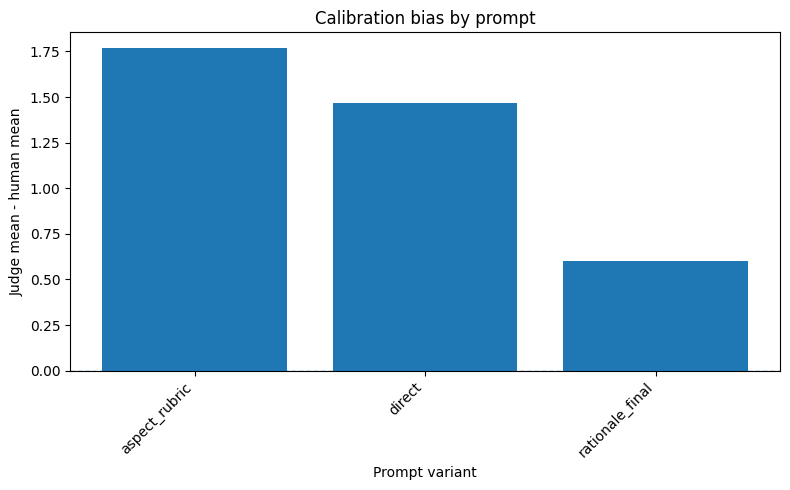

In [101]:
df_plot = df_prompt_metrics.sort_values("bias", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(df_plot["prompt_variant"], df_plot["bias"])
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Calibration bias by prompt")
plt.xlabel("Prompt variant")
plt.ylabel("Judge mean - human mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [102]:
needed_cols = ["doc_id", "segment_id", "system", "language_locale", "aspect"]

[col for col in needed_cols if col not in df_prompt_all.columns]

[]

In [103]:
df_prompt_pairwise = compute_system_pairwise_accuracy(
    df_prompt_all,
    group_cols=["prompt_variant"]
)

df_prompt_pairwise.sort_values("pairwise_accuracy", ascending=False)

,prompt_variant,pairwise_accuracy,correct_pairs,n_pairs,human_ties_ignored
1,direct,0.413333,31,75,3
0,aspect_rubric,NaN,0,0,0
2,rationale_final,NaN,0,0,0


In [104]:
df_prompt_all.groupby("prompt_variant").agg(
    total_rows=("judge_score", "size"),
    valid_judge_scores=("judge_score", "count"),
    unique_scores=("judge_score", "nunique"),
    unique_systems=("system", "nunique")
)

,total_rows,valid_judge_scores,unique_scores,unique_systems
prompt_variant,,,,
aspect_rubric,30,30,3,0
direct,30,30,3,13
rationale_final,30,30,5,0
